# 04 · Embodied — a real policy in a local closed loop

A closed loop: render a frame, the subject picks a move, step, repeat. This notebook runs a **real (tiny) neural policy** locally through the unified interface, captures its activations **each tick**, and contrasts a **passive** present-and-record pass with the **closed loop**. An oracle and a random policy are baselines; the big-VLM scaling result (Qwen2.5-VL) is an EC2 companion, referenced not run here.

*Local · torch-only · runs in seconds.*

In [1]:
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from brainscore.harnesses.grid_game import (GridGameEnv, play_game,
    greedy_oracle_policy, random_action_policy, evaluate_policy)
from brainscore.model_helpers.policy_wrapper import PolicyWrapper
from brainscore.activation_window import ActivationWindow
from brainscore_core.model_interface import BrainScoreModel
torch.manual_seed(0)

/Users/kartik/Brain-Score Unified/core/brainscore_core/metrics/__init__.py:17: FutureWarning: xarray subclass Score should explicitly define __slots__
  class Score(DataAssembly):


## The environment — one rendered frame

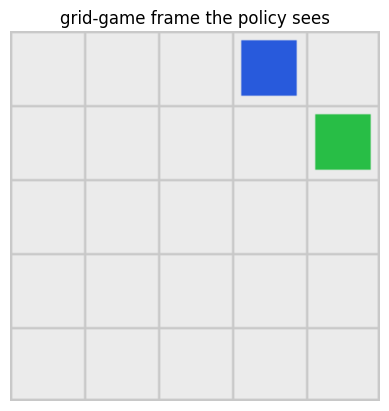

. . . P .
. . . . G
. . . . .
. . . . .
. . . . .


In [2]:
env = GridGameEnv(size=5, seed=3); obs = env.reset()
plt.imshow(obs['frame']); plt.axis('off'); plt.title('grid-game frame the policy sees'); plt.show()
print(obs['ascii'])

## A tiny neural policy, cloned from the oracle so it actually navigates

A small conv net maps a frame &rarr; 4 action logits. We behavior-clone the oracle for a few seconds so the net is a *real, functioning* policy — then wrap it as a subject via `action_fn`.

In [3]:
class TinyPolicyNet(nn.Module):
    def __init__(self, n_actions=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveMaxPool2d((6, 6)))  # keep coarse spatial layout of the sparse cells
        self.head = nn.Linear(16 * 6 * 6, n_actions)
    def forward(self, x):
        return self.head(self.features(x).flatten(1))

net = TinyPolicyNet()
def frame_to_tensor(f):
    return torch.from_numpy(np.ascontiguousarray(f)).float().permute(2,0,1).unsqueeze(0)/255.

# behavior-clone the oracle: collect (frame -> oracle action) states, then train a few epochs
X, Y = [], []
for ep in range(150):
    e = GridGameEnv(size=5, seed=1000 + ep); o = e.reset()
    for _ in range(e.max_steps):
        a = greedy_oracle_policy(o, ())
        X.append(frame_to_tensor(o['frame'])); Y.append(a)
        o, _, done, _ = e.step(a)
        if done: break
X = torch.cat(X); Y = torch.tensor(Y)
opt = torch.optim.Adam(net.parameters(), lr=2e-3)
net.train()
for epoch in range(15):
    perm = torch.randperm(len(Y))
    for i in range(0, len(Y), 64):
        idx = perm[i:i + 64]
        loss = nn.functional.cross_entropy(net(X[idx]), Y[idx])
        opt.zero_grad(); loss.backward(); opt.step()
net.eval()
train_acc = float((net(X).argmax(1) == Y).float().mean())
def neural_policy(observation, history):
    with torch.no_grad():
        return int(net(frame_to_tensor(observation['frame'])).argmax(1).item())
def make_model(policy):
    return BrainScoreModel('grid-policy', None, {}, {}, None,
                           action_fn=PolicyWrapper(policy, max_history=4))
print('cloned on %d oracle states; final loss %.3f, imitation acc %.2f' % (len(Y), float(loss.detach()), train_acc))

cloned on 490 oracle states; final loss 0.260, imitation acc 0.96


## Same interface, three policies: oracle (ceiling), random (floor), the cloned net

A *scripted* policy and a *neural* policy plug into the identical `action_fn` path, no per-policy glue.

In [4]:
mk = lambda p: make_model(p)
res = {
  'oracle':          evaluate_policy(mk, greedy_oracle_policy, n_episodes=20),
  'random':          evaluate_policy(mk, random_action_policy(0), n_episodes=20),
  'neural (cloned)': evaluate_policy(mk, neural_policy, n_episodes=20),
}
for k, v in res.items():
    print(f"{k:16s} success_rate={v['success_rate']:.2f}  mean_efficiency={v['mean_efficiency']:.2f}")

oracle           success_rate=1.00  mean_efficiency=1.00
random           success_rate=0.60  mean_efficiency=0.37
neural (cloned)  success_rate=0.55  mean_efficiency=0.91


## Passive vs closed loop, with per-tick activation capture

`ActivationWindow` hooks the net's `features` block. Passive = present frames and record (no acting). Closed loop = the net's own action changes the next frame; one capture per tick.

In [5]:
# passive: present 5 boards, record, no acting
frames = [GridGameEnv(size=5, seed=s).reset()['frame'] for s in range(5)]
with ActivationWindow(net, layers=['features']) as passive:
    for f in frames:
        with torch.no_grad(): net(frame_to_tensor(f))
print('PASSIVE :', len(passive.captures), 'captures, feature shape', tuple(passive.captures[0].shape))

# closed loop: the net drives the environment
env2 = GridGameEnv(size=5, seed=3)
with ActivationWindow(net, layers=['features']) as loop:
    result = play_game(make_model(neural_policy), env2, max_steps=15)
print('CLOSED  : solved=%s in %d ticks, actions=%s' % (result['solved'], result['steps'], result['actions']))
aligned = len(loop.captures) == len(result['actions'])
print('CAPTURES:', len(loop.captures), 'captures ==', len(result['actions']),
      'actions ->', 'ALIGNED' if aligned else 'MISALIGNED')

PASSIVE : 5 captures, feature shape (1, 16, 6, 6)
CLOSED  : solved=True in 2 ticks, actions=[3, 1]
CAPTURES: 2 captures == 2 actions -> ALIGNED


## The net genuinely processes each frame

Across distinct inputs the activations move (std &gt; 0); across the closed-loop rollout they trace the trajectory the policy actually took.

across 5 distinct boards, mean per-unit std: 0.2746  (>0 => responds to input)
across the rollout,       mean per-unit std: 0.0612


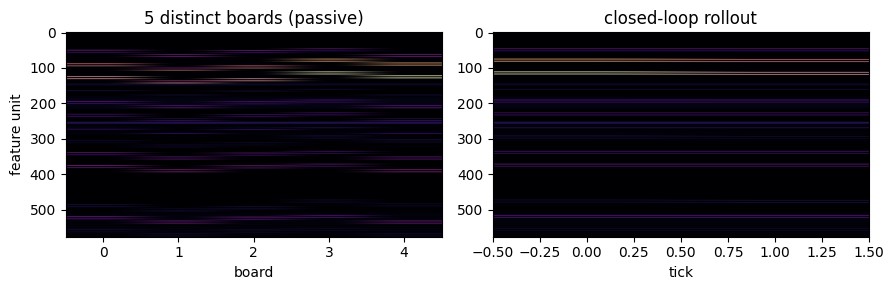

In [6]:
pf = np.stack([c.reshape(-1) for c in passive.by_layer()['features']])   # (5 boards, 16)
lf = np.stack([c.reshape(-1) for c in loop.by_layer()['features']])      # (ticks, 16)
print('across 5 distinct boards, mean per-unit std: %.4f  (>0 => responds to input)' % pf.std(0).mean())
print('across the rollout,       mean per-unit std: %.4f' % lf.std(0).mean())
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].imshow(pf.T, aspect='auto', cmap='magma'); ax[0].set_title('5 distinct boards (passive)'); ax[0].set_xlabel('board')
ax[1].imshow(lf.T, aspect='auto', cmap='magma'); ax[1].set_title('closed-loop rollout'); ax[1].set_xlabel('tick')
ax[0].set_ylabel('feature unit'); plt.tight_layout(); plt.show()

## v2 surface & reset

The runnable driver here is `play_game` (which calls `process(EnvironmentStep)`); the typed helper `run_environment` in `brainscore_core.streaming_helpers` wraps the same loop. The policy is stateless between episodes, so there is nothing to undo; `PolicyWrapper` history resets per episode.

In [7]:
from brainscore_core import streaming_helpers
print('v2 run_environment helper available:', hasattr(streaming_helpers, 'run_environment'))

v2 run_environment helper available: True


**Demonstrated:** a real, functioning neural policy closed the loop locally through one interface (`process(EnvironmentStep)`), its activations captured and aligned one-per-tick; scripted (oracle) and neural policies use the identical `action_fn` path. Big-VLM scaling on this same game is the EC2 companion (`scripts/vlm_game`).